# 1. uzdevums. ML problēmas definīcija
## 1.1. Problēmas apraksts

Manā rīcībā ir e-veikala dati, ar unikālajām sesijām, kas kopā veido 12 300 rindas.
Dati satur informāciju par lietotāju uzvedību - apmeklēto lapu skaitu, sesiju ilgumu, pirmreizējs vai atkārtots apmeklējums. Mērķis - prognozēt kuri no apmeklētājiem ir potenciālie klienti, lai labāk mērķētu reklāmas.

## 1.2 ML tipa identificēšana

Datos ir pareizā atbilde, jo dati satur kolonnu Revenue.
Mēs gribam prognozēt atbildi par katru jauno apmeklējumu.
Tas ir Supervised veids. Apkštips Classification.



## 1.3. Target un Features

Target: Revenue (Jā = pircējs, Nē = pircējs)

Skaitliskās features: Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay

Kategoriskās features: Month, VisitorType, Weekend

## 2. uzdevums. Vides sagatavošana un datu ielāde

## 2.1. Bibliotēkas un imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

## Iestatījumi


In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")

✓ Visas bibliotēkas ielādētas veiksmīgi


## 2.2. Datu ielāde

In [3]:
# Ielādē datu kopu tieši no UCI repozitorija
# to nevaru izpildīt, jo šādu ielādi man bloķē, attiecīgi dati tiek ielādēti caur Termināli

df = pd.read_csv('online_shoppers_intention.csv')

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
df.head()


Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.3. Datu sākotnējā izpēte

In [4]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)

Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


In [5]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
df.describe()

Skaitlisko kolonnu statistika:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [6]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())

Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [7]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_27488\1917500086.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


In [8]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")

Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


## 3. uzdevums. Trūkstošās vērtības

## 3.1. Vizualizē trūkstošās vērtības

In [9]:
# Kuras kolonnas satur trūkstošas vērtības?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Kolonnas ar trūkstošām vērtībām:")
print(missing)

# Vizualizācija
if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")



Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)
✓ Trūkstošo vērtību nav — dati ir tīri!


## 3.2. Apstrāde

In [10]:
# Skaitliskām kolonnām — mediāna
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")

# Kategoriskām kolonnām — moda
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")

# Galīgā pārbaude
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() =", df.isnull().sum().sum())



✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_27488\1495211090.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


## 3.3. Paskaidrojums (Markdown šūna)


Skaitliskajām kolonnām izmantoju mediānu, jo tā ir noturīgāka pret ekstrēmām vērtībām nekā vidējais aritmētiskais. Kategoriskajām kolonnām izmantoju modu (biežāko vērtību), jo tā saglabā datu sadalījumu. Šajā datu kopā trūkstošo vērtību nav, taču šī pieeja ir svarīga reālos projektos.

## 4. uzdevums. Kategorisko mainīgo kodēšana

## 4.1. Identificēšana

In [11]:
# Kādas ir kategoriskās kolonnas?
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    print(df[col].unique()[:10])  # Parāda pirmos 10


Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

VisitorType: 3 unikālas vērtības
<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_27488\1566342124.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


## 4.2. Kodēšana

## a) Boolean kolonnas → 0/1

In [12]:
# Boolean/binary kolonnas — Label Encoding
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Boolean kolonnas konvertētas uz 0/1")


✓ Boolean kolonnas konvertētas uz 0/1


## b) Kategoriskas ar vairākām vērtībām → One-Hot Encoding

In [13]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True, dtype=int)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Nākamās jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])


✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Nākamās jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='str')


## 4.3. Pārbaude

In [14]:
# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()
assert len(remaining_cat) == 0, f"Vēl neapstrādātas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikt: ", len(remaining_cat))


✓ Visas kategoriskās kolonnas kodētas. Atlikt:  0


In [15]:
# Visas kolonnas tagad ir skaitliskas
print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Dati tipi:")
print(df.dtypes.value_counts())



Kolonnu skaits pēc kodēšanas: 27
Dati tipi:
int64      20
float64     7
Name: count, dtype: int64


## 4.4. Paskaidrojums (Markdown šūna)

Weekend un Revenue - tikai True/False Label Encoding šajā gadījumā ir perfekts.
Month - 10 mēneši. Label encoding neder, jo domās, ka decembris ir 10 reizes labāks par janvāri, pieņemams ir One Hot, jo tiks izveidotas deviņs jaunas kolonas, kas nav ļoti daudz. VisiturType - One Hot, jo izveidos tikai 2 jaunas kolonas.

## 5. uzdevums. Skaitlisko kolonnu normalizācija

## 5.1. Pirms normalizācijas statistika

In [16]:
# Kādas ir skaitliskās kolonnas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:10])  # Parāda pirmos 10


Skaitliskās kolonnas (27 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


In [17]:
# Statistika PIRMS normalizācijas
print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))



=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    34.47           31.73                  1194.75  
std                    140.75           44.48                  1913.67  
min                      0.00            0.00                     0.00  
25%     

## 5.2. Normalizācija ar StandardScaler

In [18]:
# Atlasi skaļošanai VISAS skaitliskās kolonnas (izņemot target)
cols_to_scale = [col for col in numeric_cols if col != 'Revenue']


In [19]:
# StandardScaler: (x - mean) / std
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])



In [20]:
print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")
print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")
print(df[cols_to_scale[:6]].describe().round(2))


✓ 26 skaitliskās kolonnas normalizētas

=== STATISTIKA PĒC NORMALIZĀCIJAS ===


       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                     0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.41           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.77           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    -0.00            0.00                    -0.00  
std                      1.00            1.00                     1.00  
min                     -0.24           -0.71                    -0.62  
25%                     -0.24           -0.56    

## 5.3. Vizualizācija

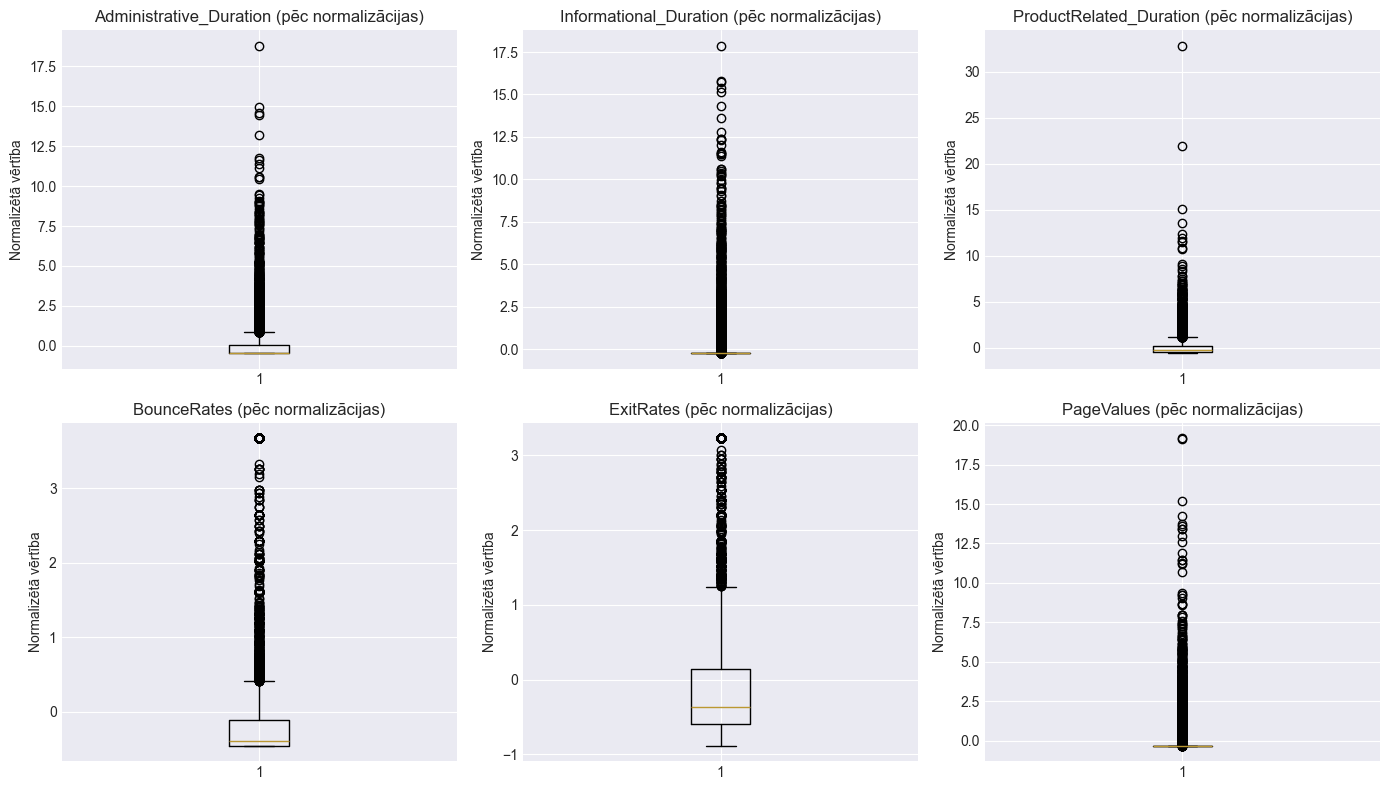

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [21]:
# Salīdzinājums:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()

print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")

## 6. uzdevums. Jauna iezīme (Feature Engineering)

## 6.1. Jauna iezīmes izveide

In [22]:
df['TotalDuration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

print("✓ Jaunas iezīmes izveidotas")
print(f"Datu kopas forma tagad: {df.shape}")

✓ Jaunas iezīmes izveidotas
Datu kopas forma tagad: (12330, 28)


## 6.2. Paskaidrojums (Markdown šūna)

Jaunā kolona atspoguļos kopējo laiku, kuru cilvēks ir pavadījis mājas lapā.
Pieļauju, ka cilvēks, kurš pētot produktus mājas lapā ir pavadījis 30 minūtes, būs 
vairāk ieinteresēts iegādāties produktu nekā cilvēks, kurš tajā ir pavadījis 15 sekundes.

## 6.3. Vizualizācija

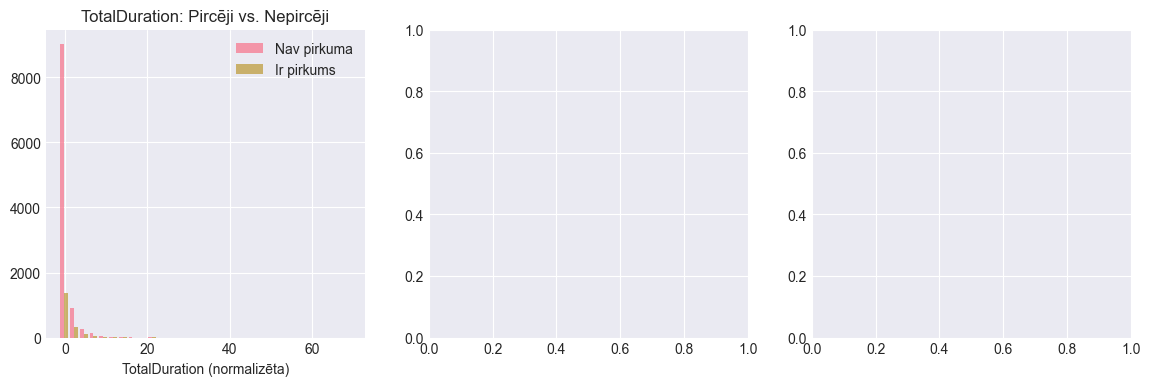

In [23]:
# Salīdzinājums: jaunā iezīme starp pircējiem un nepircējiem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Piemērs ar TotalDuration (aprēķins ir redzams slaidos)
axes[0].hist([df[df['Revenue'] == 0]['TotalDuration'],
              df[df['Revenue'] == 1]['TotalDuration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('TotalDuration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('TotalDuration (normalizēta)')
axes[0].legend()


In [24]:
# Vidējie
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['TotalDuration'].mean(),
            df[df['Revenue'] == 1]['TotalDuration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais TotalDuration')
axes[1].set_ylabel('Vērtība')

Text(399.0106209150328, 0.5, 'Vērtība')

In [25]:
# Box plot
df.boxplot(column='TotalDuration', by='Revenue', ax=axes[2])
axes[2].set_title('TotalDuration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")


<Figure size 640x480 with 0 Axes>

✓ Jaunā iezīme analizēta un vizualizēta


## 7. uzdevums. Tīrās datu kopas saglabāšana

## 7.1. Datu saglabāšana

In [26]:
# Saglabā tīro datu kopu nākamajajiem uzdevumiem
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")


✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 28


## 7.2. Pārbaude

In [27]:
# Pārbaudi, vai fails ir nolasāms
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās rindas:")
print(df_check.head(2))


✓ Fails pārbaudīts: (12330, 28)
Pirmās rindas:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Jul  Month_June  \
0     3.667189   3.229316   -0.317178   -0.308821  ...  -0.190548   -0.154649   
1    -0.457683   1.171473   -0.317178   -0.308821  ...  -0.190548   -0.154649   

   Month_Mar  Month_May  Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0  -0.427739  -0.612532  -0.566798  -0.215871  -0.194175          -0.083316   
1  -0.427739  -0.612532  -0.566798  -0.215871  -0.194175          -0.083316   

   VisitorType_Returning_Visitor  TotalDuration  
0                       0.

## 7.3. Rezumējums (Markdown šūna)

## Datu sagatavošanas rezumējums

* Pārbaudītas trūkstošās vertības
* Boolean kolonas (Weekend, Revenue) kodētas ar Label Encoding uz 0 un 1
* Month un Visitor Type kodētas ar One Hot Encoding
* Visas skaitliskās kolonnas normalizētas ar StandartScaler
* Izveidota jauna iezīme Total Duration


## Identificētās problēmas:

* Trūkstošo vērtību nav (dati bija tīri)
* Kategoriskās kolonas (Month, VisitorType, Weekend, Revenue) nebija skaitliskā         formātā, tās bija jāparveido, lai modeļi varētu ar tām strādāt
* Skaitliskajām kolonām bija ļoti atšķirīgi mērogi Duration līdz 36398, BounceRates līdz 0.2
*Izveidota jauna kolona, kas parāda kopējo mājas lapā pavadīto laiku


## Rezultāts:

* Sākotnēji 12330 rindas, 18 kolonas
* Pēc apstrādes rindu skaits saglabājās tāds pats, kolonas kļūst vairāk (One Hot pievienoja jaunas)
* Dati sagatavoti modeļu treniņam

## B DAĻA: KLASIFIKĀCIJA

## 8.1. Ielādē tīro datu kopu un definē X, y

In [28]:
# Ielādē tikko sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')

# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")



Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


## 8.2. Sadali datos treniņa un testa kopās

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:\n{y_train.value_counts(normalize=True).round(3)}")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


* Kāpēc stratify=y?
 
 nodrošina ka gan treniņa, gan testa datu kopās ir vienāda pircēju proporcija - apmēram 15% katrā, attiecīgi šādi būs vienkāršāk pārbaudīt modeļa atbilžu precizitāti.

* Kāpēc 80/20?
 
 90/10 - modelim ir vairāk datu mācībām, var pieņemt, ka mācās labāk, bet ir mazāk datu testam, attiecīgi mazāka pārliecība par datu ticamību.
 
 70/30 - mazāk datu treniņam vairāk testam, tiek izmantots, ja nepieciešams ļoti drošs tests.
 
 80/20 - zelta vidusceļš un mūsu datu kopa ir pietiekami liela, lai šo veiksmīgi realizētu.

## 9. uzdevums. Trenē trīs klasifikācijas modeļus

## 9.1. Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))


=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



## 9.2. Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))


=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



## 9.3. Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



## 10. uzdevums. Salīdzini modeļus

## 10.1. F1 score salīdzinājums

In [33]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))


            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.635258
Logistic Regression  0.481416


## 10.2. Confusion matrices blakus

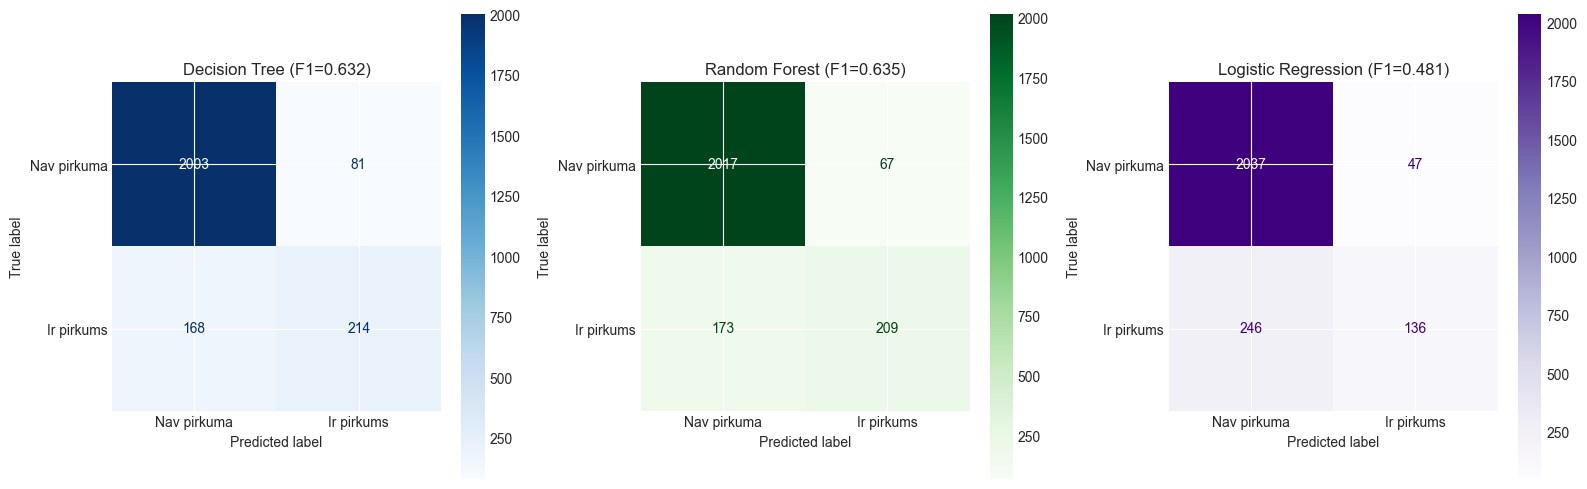

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()


## 10.3. Feature importance

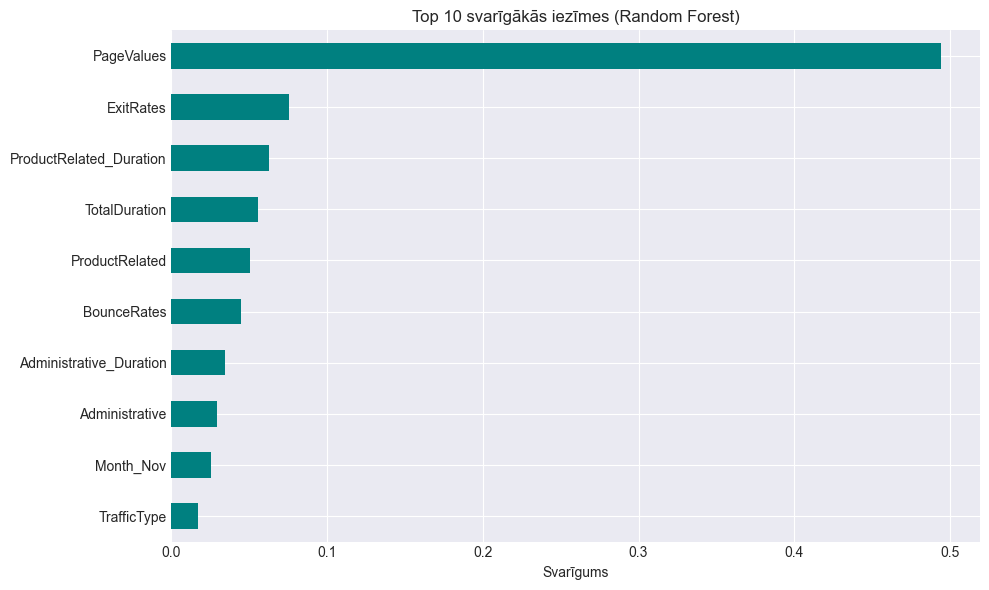

In [35]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



## 10.4. Secinājumi (Markdown šūna)

Pēc F1 Score rādītājiem labākais no modeļiem ir Random Forest ar 0.64, vājākie rezultāti bija Logistic Regression tikai 0,48. Accuracy šeit pielietot nedrīks, jo ir ļoti liels procents 'nepircēju' un pat ja modelis neatrastu nevienu pircēju pareizības rādītājs tāpat būtu 85%, kas ir ļoti augsts, bet bezjēdzīgs. Confusion Matrices testā labākais bija Random Forest, bet ļoti tuvu ir Decision Tree un no biznesa viedokļa es izvēlētos tieši šo jo precīzāk noprognozēti pareizie pircēji un mazāk pircēji palaisti garām, lai gan ir vairāk viltus pircēju, bet aizsūtīt piedāvājumu viltus pircējam ir labāk, kā neaizsūtīt reālam pircējam. Plus iespējams šie viltus pircēji ir svārstīgie pircēji, kurus pat nepieciešams uzrunāt.